Sigma function provides a transition between linear and nonlinear range of the lift curve.

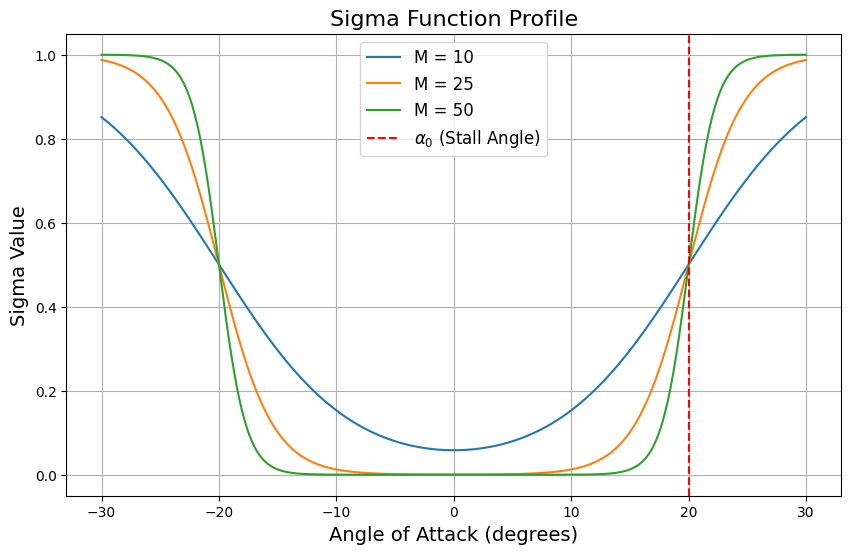

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sigma_function

# Example usage
alpha0 = np.radians(20)  # Stall angle in radians
M = 25                   # Sharpness parameter
sigma = sigma_function.SigmaFunction(alpha_0=alpha0, M=M)


# Define parameters
alpha = np.linspace(-30, 30, 500)  # Angle of attack in degrees
alpha_rad = np.radians(alpha)     # Convert to radians
M_values = [10, 25, 50]           # Different sharpness parameters

# Plot the sigma function for different values of M
plt.figure(figsize=(10, 6))
for M in M_values:
    sigma.M = M
    sigma_values = sigma.compute(alpha_rad)
    plt.plot(alpha, sigma_values, label=f'M = {M}')

# Customize the plot
plt.title("Sigma Function Profile", fontsize=16)
plt.xlabel("Angle of Attack (degrees)", fontsize=14)
plt.ylabel("Sigma Value", fontsize=14)
plt.axvline(np.degrees(alpha0), color='r', linestyle='--', label=r'$\alpha_0$ (Stall Angle)')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

The following example compares the NeuroBEM lift model profile with the fitted blended model from BEM paper. 

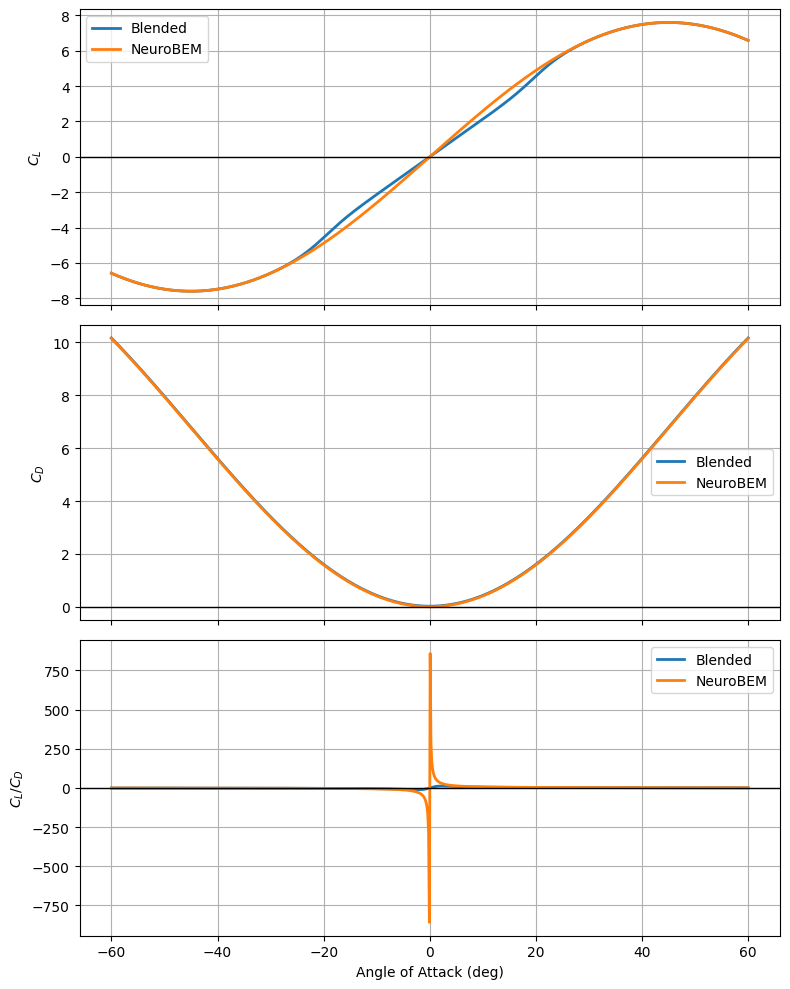

In [5]:
import aero_coeff

# Angle range
alpha_deg = np.linspace(-60, 60, 800)
alpha_rad = np.radians(alpha_deg)

# Your blended model
coeff = aero_coeff.Coeffecients(
    cl_1=15.20569 * 0.8,
    cl_2=15.20569,
    alpha_0=np.radians(20.0),
    cd=13.53063,
)
cl = coeff.get_cl(alpha_rad)
cd = coeff.get_cd(alpha_rad, 10, 0.1)
cl_cd = np.divide(cl, cd, where=cd!=0)

# NeuroBEM model
neuro = aero_coeff.NeuroBEMCoefficients(
    a=15.20569,
    d=13.53063,
    linear_mode=False
)
cl_nb = neuro.get_cl(alpha_rad)
cd_nb = neuro.get_cd(alpha_rad)
cl_cd_nb = np.divide(cl_nb, cd_nb, where=cd_nb!=0)

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# ---- CL ----
axs[0].plot(alpha_deg, cl, linewidth=2, label="Blended")
axs[0].plot(alpha_deg, cl_nb, linewidth=2, label="NeuroBEM")
axs[0].axhline(0, color='black', linewidth=1)
axs[0].set_ylabel(r"$C_L$")
axs[0].grid(True)
axs[0].legend()

# ---- CD ----
axs[1].plot(alpha_deg, cd, linewidth=2, label="Blended")
axs[1].plot(alpha_deg, cd_nb, linewidth=2, label="NeuroBEM")
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_ylabel(r"$C_D$")
axs[1].grid(True)
axs[1].legend()

# ---- CL/CD ----
axs[2].plot(alpha_deg, cl_cd, linewidth=2, label="Blended")
axs[2].plot(alpha_deg, cl_cd_nb, linewidth=2, label="NeuroBEM")
axs[2].axhline(0, color='black', linewidth=1)
axs[2].set_ylabel(r"$C_L/C_D$")
axs[2].set_xlabel("Angle of Attack (deg)")
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()